<a href="https://colab.research.google.com/github/dirgad58-commits/ML-Klasifikasi_kualitas_air--L.M.Dirga_07-/blob/main/Kualitas_Air.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

TAHAP EKSPLORASI DATA (EDA)
Ukuran dataset: 3949 baris, 14 kolom

5 baris pertama:
  Country             Area Waterbody Type        Date Ammonia (mg/l)  \
0  Canada  SE649035-145565          River  12/01/1974       0.059248   
1  Canada  SE649035-145565          River  12/01/1975     0.03982071   
2  Canada  SE649035-145565          River  12/01/1976     0.03134129   
3  Canada  SE649035-145565          River  12/01/1977     0.02050071   
4  Canada  SE649035-145565          River  12/01/1978    0.020022604   

  Biochemical Oxygen Demand (mg/l) Dissolved Oxygen (mg/l)  \
0                              1.3                    8.15   
1                             1.38                     7.8   
2                             2.23                     7.8   
3                             1.61                    8.15   
4                             1.64                  43.708   

  Orthophosphate (mg/l) pH (ph units) Temperature (cel)  Nitrogen (mg/l)  \
0             0.0119167         8.0

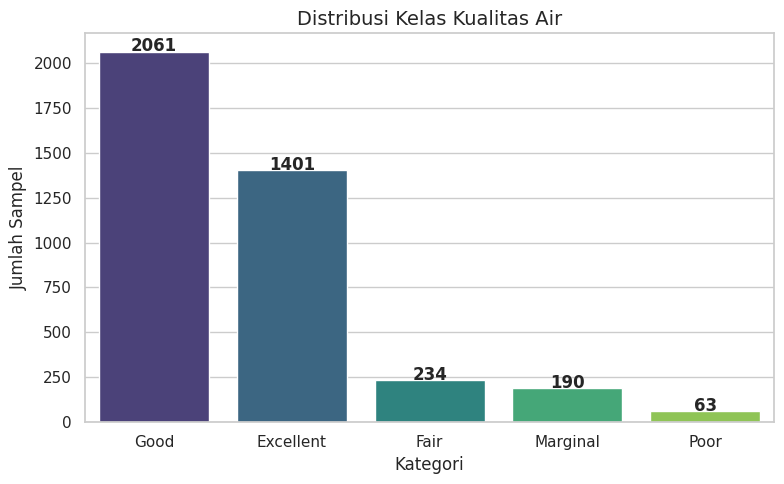


Missing values per kolom:
Tidak ada missing values.

Statistik deskriptif kolom numerik:
       Nitrogen (mg/l)
count      3949.000000
mean         13.413500
std          71.948432
min           0.000000
25%           0.400000
50%           0.400000
75%           0.400000
max         903.307000


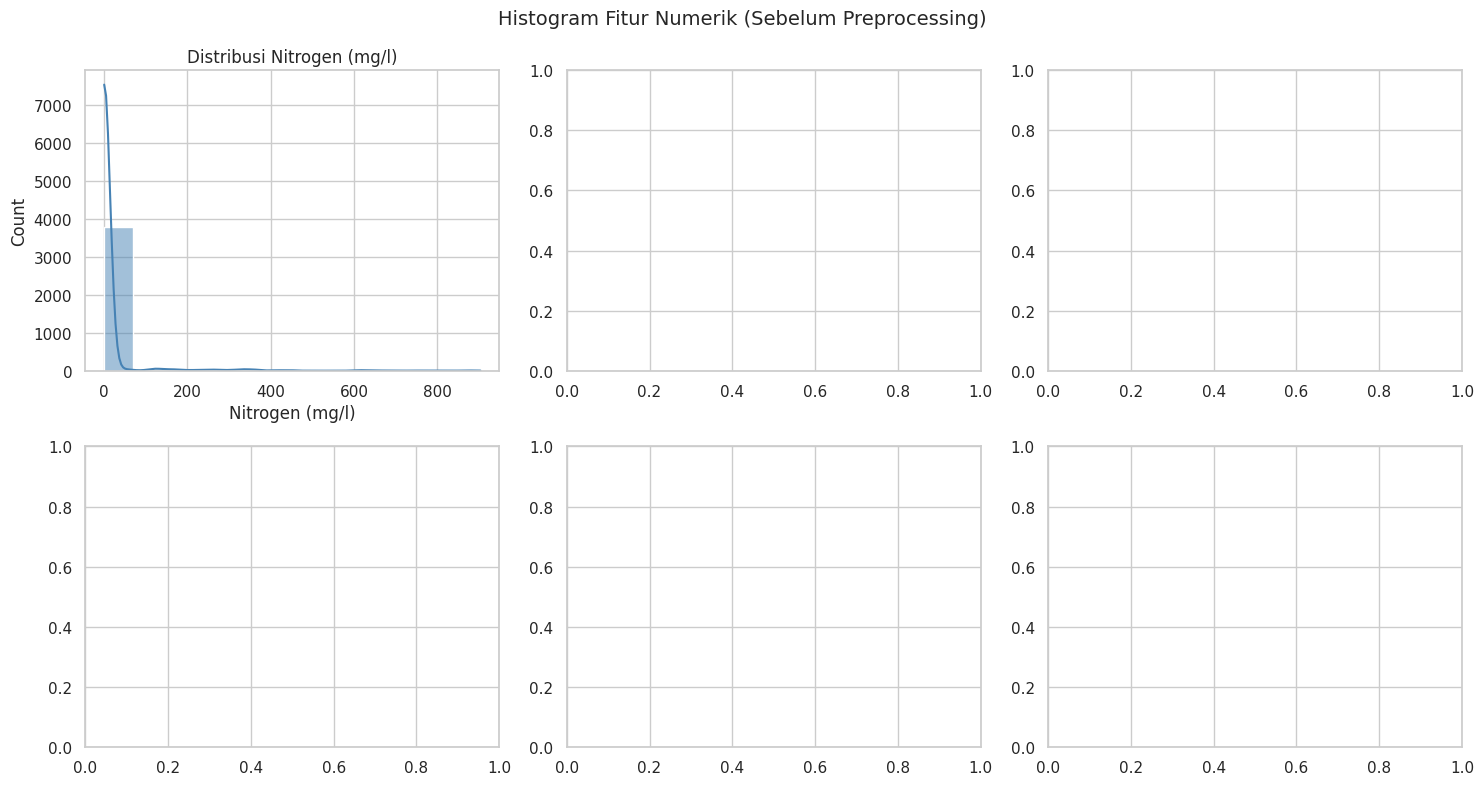

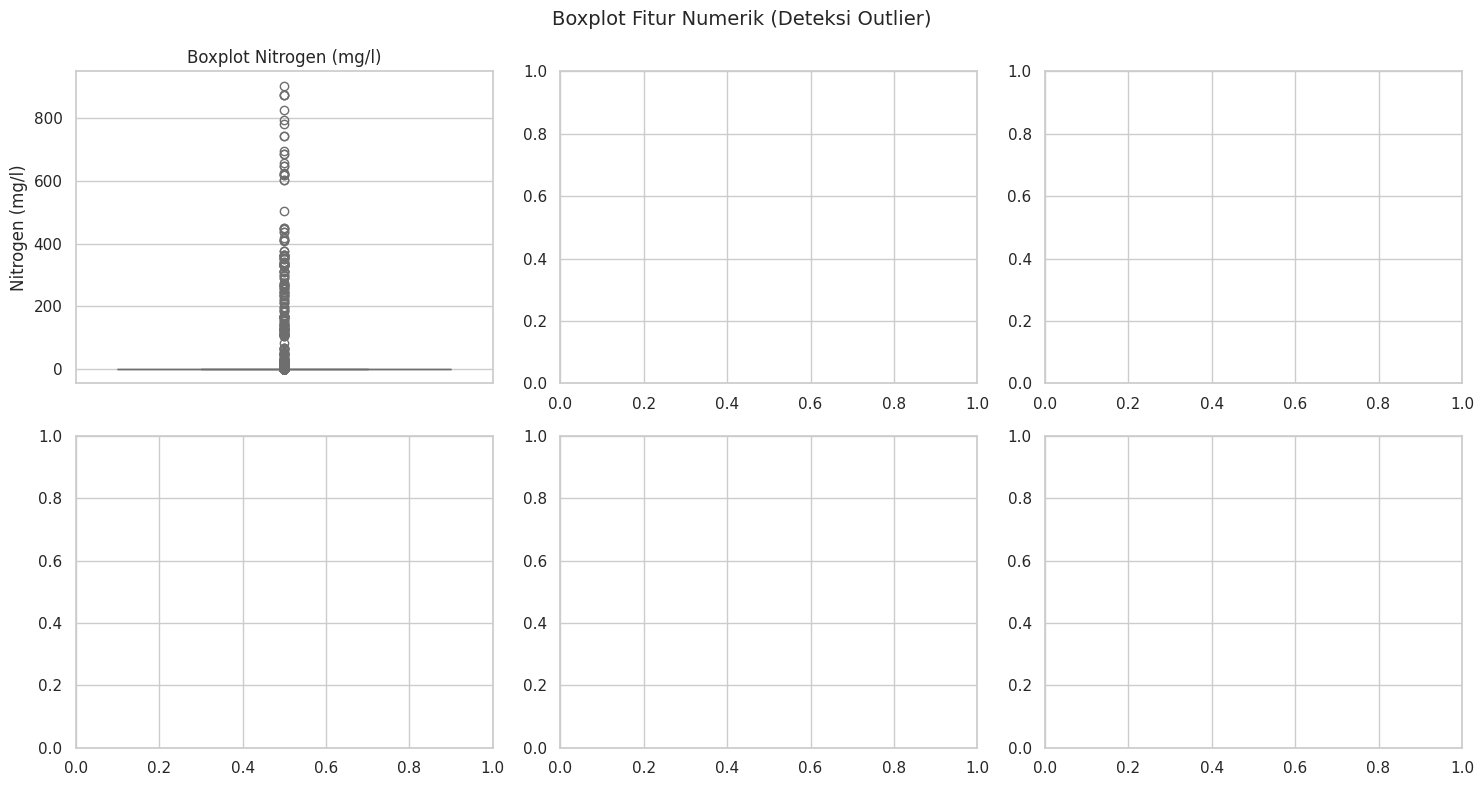


TAHAP PREPROCESSING DAN PEMODELAN

Jumlah missing values per kolom setelah konversi:
Ammonia (mg/l)                        65
Biochemical Oxygen Demand (mg/l)      86
Dissolved Oxygen (mg/l)             1104
Orthophosphate (mg/l)                 19
pH (ph units)                         38
Temperature (cel)                    800
Nitrogen (mg/l)                        0
Nitrate (mg/l)                      1550
CCME_WQI                               0
dtype: int64

Kelas target: ['Excellent' 'Fair' 'Good' 'Marginal' 'Poor']

Training set: 3159 sampel
Test set: 790 sampel

Melatih model: Random Forest
Akurasi pada test set: 0.9380
Cross-validation (5-fold) mean akurasi: 0.9370 (+/- 0.0098)

Classification Report:
              precision    recall  f1-score   support

   Excellent       0.93      0.99      0.96       280
        Fair       0.81      0.72      0.76        47
        Good       0.96      0.95      0.96       412
    Marginal       0.83      0.66      0.74        38
        

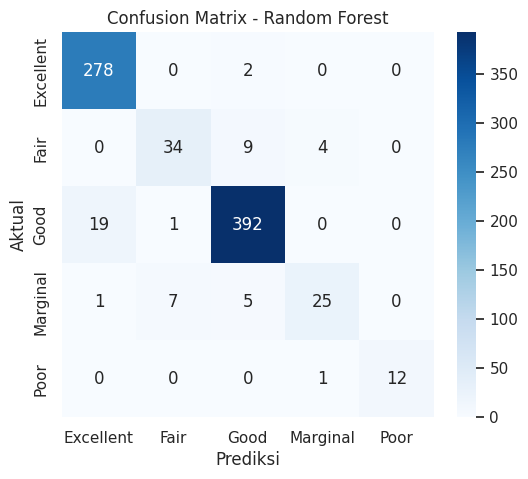

Model Random Forest telah disimpan ke 'water_quality_model_random_forest.pkl'

Melatih model: XGBoost
Akurasi pada test set: 0.9418
Cross-validation (5-fold) mean akurasi: 0.9411 (+/- 0.0049)

Classification Report:
              precision    recall  f1-score   support

   Excellent       0.95      1.00      0.97       280
        Fair       0.80      0.77      0.78        47
        Good       0.97      0.96      0.96       412
    Marginal       0.78      0.66      0.71        38
        Poor       0.83      0.77      0.80        13

    accuracy                           0.94       790
   macro avg       0.87      0.83      0.85       790
weighted avg       0.94      0.94      0.94       790



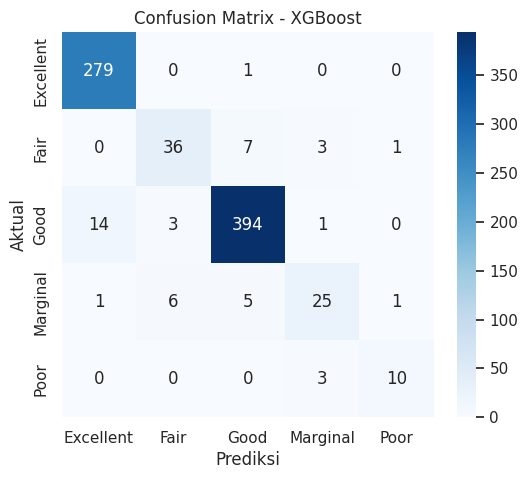

Model XGBoost telah disimpan ke 'water_quality_model_xgboost.pkl'

Melatih model: Gradient Boosting
Akurasi pada test set: 0.9494
Cross-validation (5-fold) mean akurasi: 0.9456 (+/- 0.0062)

Classification Report:
              precision    recall  f1-score   support

   Excellent       0.97      1.00      0.98       280
        Fair       0.78      0.77      0.77        47
        Good       0.97      0.97      0.97       412
    Marginal       0.76      0.66      0.70        38
        Poor       0.79      0.85      0.81        13

    accuracy                           0.95       790
   macro avg       0.85      0.85      0.85       790
weighted avg       0.95      0.95      0.95       790



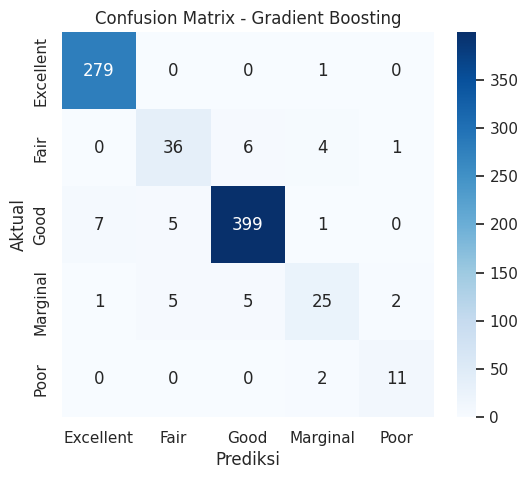

Model Gradient Boosting telah disimpan ke 'water_quality_model_gradient_boosting.pkl'

Label encoder disimpan ke 'label_encoder.pkl'

RINGKASAN PERBANDINGAN MODEL
            Model  Test Accuracy  CV Mean Accuracy   CV Std
    Random Forest       0.937975          0.937002 0.009802
          XGBoost       0.941772          0.941118 0.004874
Gradient Boosting       0.949367          0.945551 0.006230

Fitur terpilih oleh mutual information (k=10): ['Ammonia (mg/l)', 'Biochemical Oxygen Demand (mg/l)', 'Dissolved Oxygen (mg/l)', 'Orthophosphate (mg/l)', 'pH (ph units)', 'Temperature (cel)', 'Nitrogen (mg/l)', 'Nitrate (mg/l)']

MENYIMPAN KETIGA MODEL DALAM SATU FILE
✓ Ketiga model beserta komponen preprocessing disimpan dalam satu file:
   'saved_models/all_models_components.pkl'


In [ ]:
# =============================================
# Judul: Klasifikasi Multi-Level Kualitas Air Menggunakan Machine Learning
#        dengan Teknik Imputation dan Feature Selection
# Model: Random Forest, XGBoost, Gradient Boosting
# =============================================

# 1. Import library yang diperlukan
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

import warnings
warnings.filterwarnings('ignore')

# =============================================
# TAMBAHAN: EDA LENGKAP SEBELUM PREPROCESSING
# =============================================
print("="*60)
print("TAHAP EKSPLORASI DATA (EDA)")
print("="*60)

# 2. Membaca dataset
file_path = 'Canada_dataset.csv'
df = pd.read_csv(file_path, sep=';')
print(f"Ukuran dataset: {df.shape[0]} baris, {df.shape[1]} kolom\n")
print("5 baris pertama:")
print(df.head())

# 2.1 Distribusi target
print("\nDistribusi kelas target (CCME_WQI):")
target_counts = df['CCME_WQI'].value_counts()
print(target_counts)

plt.figure(figsize=(8,5))
sns.countplot(data=df, x='CCME_WQI', order=target_counts.index, palette='viridis')
plt.title('Distribusi Kelas Kualitas Air', fontsize=14)
plt.xlabel('Kategori')
plt.ylabel('Jumlah Sampel')
for i, v in enumerate(target_counts.values):
    plt.text(i, v+2, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

# 2.2 Missing values
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print("\nMissing values per kolom:")
if len(missing) > 0:
    print(missing)
    plt.figure(figsize=(10,4))
    missing.plot(kind='bar', color='salmon')
    plt.title('Missing Values Sebelum Preprocessing')
    plt.ylabel('Jumlah Missing')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print("Tidak ada missing values.")

# 2.3 Statistik deskriptif
print("\nStatistik deskriptif kolom numerik:")
print(df.describe())

# 2.4 Histogram fitur numerik (sebelum cleaning)
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
# Hapus kolom yang tidak relevan
ignore = ['CCME_Values']
numeric_cols = [c for c in numeric_cols if c not in ignore]

if numeric_cols:
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    axes = axes.flatten()
    for i, col in enumerate(numeric_cols[:6]):
        sns.histplot(df[col].dropna(), kde=True, ax=axes[i], color='steelblue')
        axes[i].set_title(f'Distribusi {col}')
    plt.suptitle('Histogram Fitur Numerik (Sebelum Preprocessing)', fontsize=14)
    plt.tight_layout()
    plt.show()

# 2.5 Boxplot untuk outlier
if numeric_cols:
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    axes = axes.flatten()
    for i, col in enumerate(numeric_cols[:6]):
        sns.boxplot(y=df[col].dropna(), ax=axes[i], color='lightcoral')
        axes[i].set_title(f'Boxplot {col}')
    plt.suptitle('Boxplot Fitur Numerik (Deteksi Outlier)', fontsize=14)
    plt.tight_layout()
    plt.show()

# 2.6 Matriks korelasi (heatmap)
if len(numeric_cols) > 1:
    corr = df[numeric_cols].corr()
    plt.figure(figsize=(12, 10))
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', center=0,
                square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
    plt.title('Matriks Korelasi Antar Fitur Numerik', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

# =============================================
# LANJUTAN PREPROCESSING
# =============================================
print("\n" + "="*60)
print("TAHAP PREPROCESSING DAN PEMODELAN")
print("="*60)

# 3. Menentukan target dan fitur
cols_to_drop = ['Country', 'Area', 'Waterbody Type', 'Date', 'CCME_Values']
df_clean = df.drop(columns=cols_to_drop, errors='ignore')

# 4. Konversi kolom numerik (tangani format ribuan)
for col in df_clean.columns:
    if col != 'CCME_WQI':
        df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

print("\nJumlah missing values per kolom setelah konversi:")
print(df_clean.isnull().sum())

# 5. Pisahkan fitur dan target
X = df_clean.drop('CCME_WQI', axis=1)
y = df_clean['CCME_WQI']

# 6. Encode target
le = LabelEncoder()
y_encoded = le.fit_transform(y)
print("\nKelas target:", le.classes_)

# 7. Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)
print(f"\nTraining set: {X_train.shape[0]} sampel")
print(f"Test set: {X_test.shape[0]} sampel")

# 8. Pipeline preprocessing (imputer + selector) yang sama untuk semua model
imputer = SimpleImputer(strategy='median')
selector = SelectKBest(score_func=mutual_info_classif, k=10)

def create_pipeline(classifier):
    return Pipeline([
        ('imputer', imputer),
        ('selector', selector),
        ('classifier', classifier)
    ])

# 9. Inisialisasi ketiga model
models = {
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'XGBoost': XGBClassifier(n_estimators=100, random_state=42, use_label_encoder=False, eval_metric='mlogloss'),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42)
}

# 10. Melatih, mengevaluasi, dan menyimpan setiap model (ke file terpisah)
results = {}
best_model = None
best_acc = 0
best_name = ""

for name, clf in models.items():
    print(f"\n{'='*50}")
    print(f"Melatih model: {name}")

    pipeline = create_pipeline(clf)
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"Akurasi pada test set: {acc:.4f}")

    cv_scores = cross_val_score(pipeline, X_train, y_train, cv=StratifiedKFold(5, shuffle=True, random_state=42))
    print(f"Cross-validation (5-fold) mean akurasi: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

    results[name] = {
        'pipeline': pipeline,
        'test_accuracy': acc,
        'cv_mean': cv_scores.mean(),
        'cv_std': cv_scores.std(),
        'y_pred': y_pred
    }

    if acc > best_acc:
        best_acc = acc
        best_model = pipeline
        best_name = name

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=le.classes_))

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
    plt.title(f'Confusion Matrix - {name}')
    plt.xlabel('Prediksi')
    plt.ylabel('Aktual')
    plt.show()

    # Simpan model individual
    model_filename = f'water_quality_model_{name.lower().replace(" ", "_")}.pkl'
    joblib.dump(pipeline, model_filename)
    print(f"Model {name} telah disimpan ke '{model_filename}'")

# 11. Simpan label encoder
encoder_filename = 'label_encoder.pkl'
joblib.dump(le, encoder_filename)
print(f"\nLabel encoder disimpan ke '{encoder_filename}'")

# 12. Ringkasan perbandingan model
print("\n" + "="*50)
print("RINGKASAN PERBANDINGAN MODEL")
print("="*50)
comparison = pd.DataFrame({
    'Model': list(results.keys()),
    'Test Accuracy': [results[m]['test_accuracy'] for m in results],
    'CV Mean Accuracy': [results[m]['cv_mean'] for m in results],
    'CV Std': [results[m]['cv_std'] for m in results]
})
print(comparison.to_string(index=False))

# 13. Fitur terpilih (menggunakan model terbaik)
best_selector = best_model.named_steps['selector']
selected_indices = best_selector.get_support(indices=True)
selected_features = X.columns[selected_indices]
print(f"\nFitur terpilih oleh mutual information (k=10): {list(selected_features)}")

# 14. Feature importance jika model terbaik adalah Random Forest
if isinstance(best_model.named_steps['classifier'], RandomForestClassifier):
    rf_clf = best_model.named_steps['classifier']
    X_train_imputed = best_model.named_steps['imputer'].transform(X_train)
    X_train_selected = best_selector.transform(X_train_imputed)
    importances = rf_clf.feature_importances_
    indices = np.argsort(importances)[::-1]
    plt.figure(figsize=(10,6))
    plt.title("Feature Importance (Random Forest)")
    plt.bar(range(len(importances)), importances[indices])
    plt.xticks(range(len(importances)), [selected_features[i] for i in indices], rotation=45)
    plt.tight_layout()
    plt.show()

# =============================================
# TAMBAHAN: SIMPAN KETIGA MODEL DALAM SATU FILE
# =============================================
print("\n" + "="*50)
print("MENYIMPAN KETIGA MODEL DALAM SATU FILE")
print("="*50)

os.makedirs('saved_models', exist_ok=True)

all_components = {
    'random_forest': results['Random Forest']['pipeline'],
    'xgboost': results['XGBoost']['pipeline'],
    'gradient_boosting': results['Gradient Boosting']['pipeline'],
    'label_encoder': le,
    'selected_features': selected_features.tolist(),
    'all_feature_names': X.columns.tolist(),
    'best_model_name': best_name,
    'best_accuracy': best_acc,
    'model_performance': {
        'Random Forest': results['Random Forest']['test_accuracy'],
        'XGBoost': results['XGBoost']['test_accuracy'],
        'Gradient Boosting': results['Gradient Boosting']['test_accuracy']
    }
}

joblib.dump(all_components, 'saved_models/all_models_components.pkl')
print("✓ Ketiga model beserta komponen preprocessing disimpan dalam satu file:")
print("   'saved_models/all_models_components.pkl'")

